<h1>Categorical VAE</h1>

In [1]:
import torch
import torch.nn as nn
import torch.distributions as dist
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt
import random

In [2]:
# 設置種子
seed = 88   # 42 bin
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(type(device))
print(device)

<class 'torch.device'>
cpu


# Dataset

In [4]:
dataset_train = datasets.MNIST('./datasets',
                               train=True,
                               download=False,
                               transform=transforms.ToTensor())
dataset_test = datasets.MNIST('./datasets',
                              train=False,
                              download=False,
                              transform=transforms.ToTensor())

# Model

In [5]:
class CategoricalVAE(nn.Module):
    
    def __init__(self, N, K):
        
        super().__init__()

        self.N = N
        self.K = K
        self.temperature = 1.0
        
        self.encoder = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(),
            nn.Linear(512, 256),
            nn.LeakyReLU(),
            nn.Linear(256, self.N * self.K)
        )
        
        self.decoder = torch.nn.Sequential(
            nn.Linear(self.N * self.K, 256),
            nn.LeakyReLU(),
            nn.Linear(256, 512),
            nn.LeakyReLU(),
            nn.Linear(512, 784),
            nn.Sigmoid()
        )
        
    def encode(self, inputs):
        '''
        input
        - inputs.shape: [batch_size, flatten_img_size]
        output
        - logits.shape: [batch_size, N*K]
        '''
        logits = self.encoder(inputs)
        return logits

    def decode(self, latent_codes):
        '''
        input
        - latent_codes.shape: [batch_size, N*K]
        output
        - outputs.shape: [batch_size, flatten_img_size]
        '''
        outputs = self.decoder(latent_codes)
        return outputs

    def gumbel_dist(self, shape, eps=1e-20):
        '''
        input
        - shape.shape: [batch_size, N*K]
        output
        - gumbel_noise.shape: [batch_size, N*K]
        '''
        U = torch.rand(shape)
        gumbel_noise = -torch.log(-torch.log(U + eps) + eps)
        return gumbel_noise

    def gumbel_softmax(self, logits, temperature):
        '''
        input
        - logits.shape: [batch_size, N*K]
        - temperature.shape: [1]
        output
        - latent_codes.shape: [batch_size, N*K]
        '''
        # Reshape to [batch_size*N, K]
        batch_size = len(logits)
        logits = logits.view(batch_size * self.N, self.K)
        gumbel_noise = self.gumbel_dist(logits.shape)
        y = logits + gumbel_noise
        latent_codes = nn.functional.softmax(y / temperature, dim=-1)

        # Reshape back to [batch_size, N*K]
        logits = logits.view(batch_size, self.N * self.K)
        latent_codes = latent_codes.view(batch_size, self.N * self.K)

        return latent_codes
    
    def forward(self, inputs, temperature):
        '''
        input
        - inputs.shape: [batch_size, flatten_img_size]
        output
        - logits.shape: [batch_size, N*K]
        - latent_codes.shape: [batch_size, N*K]
        - outputs.shape: [batch_size, flatten_img_size]
        '''
        logits = self.encode(inputs)
        latent_codes = self.gumbel_softmax(logits, temperature)
        outputs = self.decoder(latent_codes)
        return logits, latent_codes, outputs

# Train

In [6]:
batch_size = 100
epochs = 10
learning_rate = 0.001
initial_temperature = 0.1
minimum_temperature = 0.01
temperature_anneal_rate = 0.00003
K = 10    # number of classes
N = 30    # number of categorical distributions

In [7]:
# DataLoader
dataloader_train = DataLoader(dataset=dataset_train,
                              batch_size=batch_size,
                              shuffle=False)

In [8]:
# Loss Function
def cat_kl_div(logits):
    '''
    input
    - logits.shape: [batch_size, N*K]
    output
    - kl.shape: [batch_size, N]
    '''
    # Reshape to [batch_size*N, K]
    batch_size = len(logits)
    logits = logits.view(batch_size*N, K)
    
    q = dist.Categorical(logits=logits)
    p = dist.Categorical(probs=torch.full((batch_size*N, K), 1.0/K)) # uniform bunch of K-class categorical distributions
    kl = dist.kl.kl_divergence(q, p) # kl is of shape [B*N]
    return kl

def loss_func(outputs, labels, logits):
    '''
    input
    - outputs.shape: [batch_size, flatten_img_size]
    - labels.shape: [batch_size, flatten_img_size]
    - logits.shape: [batch_size, N*K]
    output
    - kl_loss.shape: []
    - rec_loss.shape: []
    - loss.shape: []
    '''
    
    # rec_loss = nn.functional.binary_cross_entropy(outputs, labels, reduction="mean")
    aaa = nn.MSELoss()
    rec_loss = aaa(outputs, labels)
    
    kl_loss = torch.mean(cat_kl_div(logits))

    alpha = 1
    beta = 0.03
    loss =  alpha*rec_loss + beta*kl_loss
    
    return alpha*rec_loss, beta*kl_loss, loss

In [9]:
model = CategoricalVAE(N, K)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
temperature = initial_temperature

In [10]:
# Train
# 檢查梯度的啟用狀態
for name, param in model.named_parameters():
    print(f"Layer {name}: requires_grad = {param.requires_grad}")
print("------------------------------------------")

model.train()

for epoch in range(epochs):
    
    total_kl_loss  = 0
    total_rec_loss = 0
    total_loss     = 0
    
    cnt = 0
    
    for data, _ in dataloader_train:
        '''
        data.shape: [batch_size, num_of_channel=1, img_width=28, img_height=28]
        '''
        
        # Clear Gradients
        model.zero_grad()

        # Reshape the Input Images
        img_width, img_height = len(data[0][0]), len(data[0][0][0])
        inputs = data.view(-1, img_width*img_height)    # deprecate the dimension of num_of_channel since it's 1
        '''
        inputs.shape: [batch_size, flatten_img_size]
        '''
        
        # Forward
        logits, latent_codes, outputs = model(inputs, temperature)
        '''
        - logits.shape: [batch_size, N*K]
        - latent_codes.shape: [batch_size, N*K]
        - outputs.shape: [batch_size, flatten_img_size]
        '''
        
        # 計算loss
        rec_loss, kl_loss, loss = loss_func(outputs, inputs, logits)    # 一個batch平均的loss
        total_rec_loss += rec_loss.item()
        total_kl_loss  += kl_loss.item()
        total_loss     += loss.item()
        
        # Backward & Update the parameters
        loss.backward()
        optimizer.step()

    # 看梯度
    # for name, param in model.named_parameters():
    #     if param.grad is not None:
    #         print(f"Layer {name}: Gradient norm: {param.grad.norm()}")
    #     else:
    #         print(f"Layer {name}: No gradient computed!")

    cnt += 1
    temperature = np.maximum(initial_temperature*np.exp(-temperature_anneal_rate*cnt), minimum_temperature)

    # 一個epoch平均的loss
    avg_rec_loss = total_rec_loss / len(dataloader_train)
    avg_kl_loss  = total_kl_loss / len(dataloader_train)
    avg_loss     = total_loss / len(dataloader_train)
    print(f"{epoch+1:>3}. avg_loss: {avg_loss:.7f}, avg_rec_loss: {avg_rec_loss:.7f}, avg_kl_loss: {avg_kl_loss:.7f}")

Layer encoder.0.weight: requires_grad = True
Layer encoder.0.bias: requires_grad = True
Layer encoder.2.weight: requires_grad = True
Layer encoder.2.bias: requires_grad = True
Layer encoder.4.weight: requires_grad = True
Layer encoder.4.bias: requires_grad = True
Layer decoder.0.weight: requires_grad = True
Layer decoder.0.bias: requires_grad = True
Layer decoder.2.weight: requires_grad = True
Layer decoder.2.bias: requires_grad = True
Layer decoder.4.weight: requires_grad = True
Layer decoder.4.bias: requires_grad = True
------------------------------------------
  1. avg_loss: 0.0668485, avg_rec_loss: 0.0655810, avg_kl_loss: 0.0012675
  2. avg_loss: 0.0590030, avg_rec_loss: 0.0554247, avg_kl_loss: 0.0035784
  3. avg_loss: 0.0544988, avg_rec_loss: 0.0489757, avg_kl_loss: 0.0055231
  4. avg_loss: 0.0502514, avg_rec_loss: 0.0430575, avg_kl_loss: 0.0071939
  5. avg_loss: 0.0480468, avg_rec_loss: 0.0401296, avg_kl_loss: 0.0079172
  6. avg_loss: 0.0466982, avg_rec_loss: 0.0384758, avg_kl_l

In [11]:
# Save Model
# torch.save(model.state_dict(), 'catVAE_model_weights.pth')

# Test

In [12]:
# Load Model
# model.load_state_dict(torch.load('catVAE_model_weights.pth', weights_only=True))

In [13]:
batch_size = 2

In [14]:
# DataLoader
dataloader_test = DataLoader(dataset=dataset_test,
                             batch_size=batch_size,
                             shuffle=False)

In [15]:
data_test_iter = iter(dataloader_test)
next(data_test_iter)
next(data_test_iter)
next(data_test_iter)
next(data_test_iter)
next(data_test_iter)
next(data_test_iter)
next(data_test_iter)
next(data_test_iter)#8
next(data_test_iter)

[tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]]],
 
 
         [[[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]]]]),
 tensor([9, 7])]

In [16]:
# Show Image
plt.rcParams['figure.figsize'] = (10.0, 8.0)
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

def show_logits(logits):
    '''
    input
    - logits.shape: [batch_size, N*K]
    '''
    sqrtn = int(np.ceil(np.sqrt(logits.shape[0])))
    for index, logit in enumerate(logits):
        plt.subplot(sqrtn, sqrtn, index+1)
        plt.imshow(logit.reshape(N, K))
        plt.axis('off')
    plt.show()

def show_images(images):
    '''
    input
    - images.shape: [batch_size, 28*28]
    '''
    sqrtn = int(np.ceil(np.sqrt(images.shape[0])))
    for index, image in enumerate(images):
        plt.subplot(sqrtn, sqrtn, index+1)
        plt.imshow(image.reshape(28, 28))
        plt.axis('off')
    plt.show()

inputs.shape: torch.Size([2, 784])


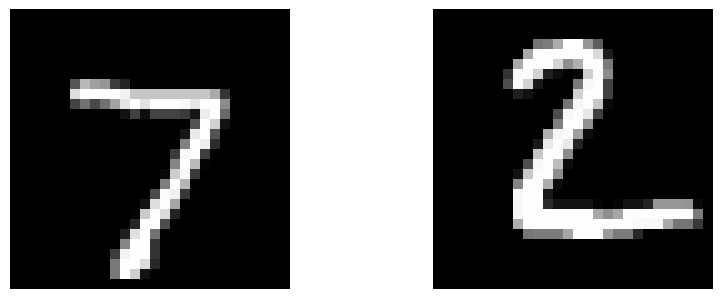

logits.shape: torch.Size([2, 300])


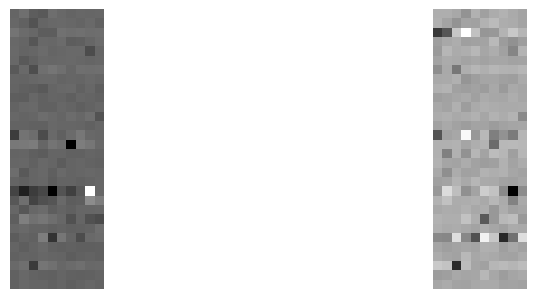

latent_code.shape: torch.Size([2, 300])


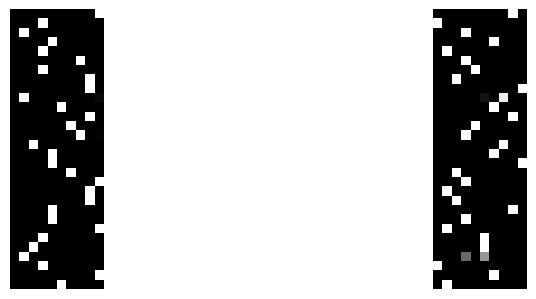

outputs.shape: torch.Size([2, 784])


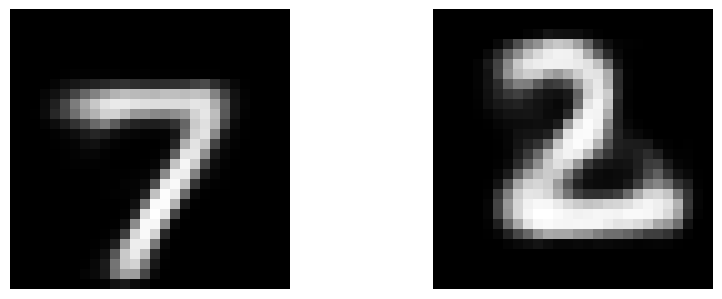

In [17]:
model.eval()

with torch.no_grad():
    
    for data, _ in dataloader_test:
    
        inputs = data.view(-1, 28*28)
        print("inputs.shape:", inputs.shape)
    
        # Inputs
        show_images(inputs)
    
        # Inference/Forward
        logits, latent_code, outputs = model(inputs, temperature=0.01)
        '''
        - logits.shape: [batch_size, N*K]
        - latent_codes.shape: [batch_size, N*K]
        - outputs.shape: [batch_size, flatten_img_size]
        '''
        
        # Logits
        print("logits.shape:", logits.shape)
        show_logits(logits)

        # Latent Code
        print("latent_code.shape:", latent_code.shape)
        show_logits(latent_code)
        
        # Outputs
        outputs = outputs.view(-1, 28*28)
        print("outputs.shape:", outputs.shape)
        show_images(outputs)

        # 用得到的logits丟到decode看生出來的會不會一樣
        # model.decode(logits)
        
        break

# Generation

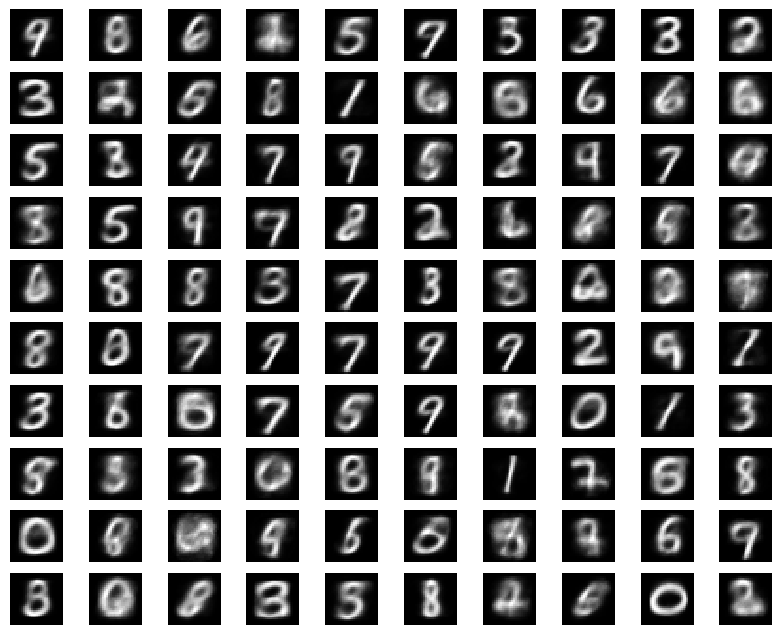

In [18]:
batch_size = 100
temperature = 0.01
with torch.no_grad():
    logits = torch.rand((batch_size, N, K))
    latent_code = model.gumbel_softmax(logits, temperature)
    gen_img = model.decode(latent_code)
    show_images(gen_img)